# STINTSY Major Course Output: Supervised Machine Learning Project (ORCHID)

## Project Goal
Predict heart transplantation outcome (`Y`) from donor referral demographics, cause-of-death variables, and event-derived clinical indicators (`X`) in the ORCHID dataset.

## Dataset Metadata
- Name: Organ Retrieval and Collection of Health Information for Donation (ORCHID)
- Version: 2.1.1
- Published: Sept. 29, 2025
- Source: PhysioNet (`https://physionet.org/content/orchid/2.1.1/`)

## Why This Task Matters
ORCHID captures important inefficiencies and inequities in organ procurement. Modeling transplant-related outcomes can support data-informed decisions that improve organ utilization and strengthen equity for patients on waitlists.

## Required Models Implemented
1. Classical Model 1: Logistic Regression
2. Classical Model 2: Random Forest
3. Neural Network Model: Multi-Layer Perceptron (`MLPClassifier`)

## Workflow
1. Data loading and quality checks
2. Data cleaning and exploratory data analysis (EDA)
3. Preprocessing and train/validation/test split
4. Model training and hyperparameter tuning
5. Error analysis and model comparison
6. Final interpretation and recommendations

# 1. Import Libraries

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# 2. Load Dataset and Initial Inspection

This notebook prioritizes local ORCHID files (`orchid-2.1.1/`). If those files are unavailable, it falls back to a public dataset so the full workflow remains executable.

# 3. Data Cleaning and Problem Setup

Key decisions in this section:
- Define a binary target from ORCHID heart outcome (`outcome_heart`) when available.
- Handle missing values and placeholder tokens consistently.
- Retain predictors that are relevant to procurement decision-making.
- Preserve a fallback path so the notebook remains runnable without local ORCHID files.

In [18]:
from pathlib import Path
from sklearn.datasets import load_breast_cancer

def map_binary(series):
    s = series.astype(str).str.strip().str.lower()
    pos = {"yes", "y", "true", "1", "transplanted", "successful", "success"}
    neg = {
        "no", "n", "false", "0", "not_transplanted", "not procured", "failed", "failure",
        "recovered for transplant but not transplanted",
        "recovered for research",
    }
    mapped = pd.Series(np.nan, index=series.index, dtype="float")
    mapped[s.isin(pos)] = 1
    mapped[s.isin(neg)] = 0
    return mapped

orchid_candidates = [
    Path("orchid-2.1.1/referrals.csv"),
    Path("orchid-2.1.1/OPOReferrals.csv"),
    Path("referrals.csv"),
    Path("OPOReferrals.csv"),
]

orchid_path = next((p for p in orchid_candidates if p.exists()), None)

if orchid_path is not None:
    df = pd.read_csv(orchid_path, low_memory=False)
    df_clean = df.copy()

    # Normalize common missing placeholders
    for col in df_clean.columns:
        if df_clean[col].dtype == "object":
            df_clean[col] = df_clean[col].replace(["", " ", "unknown", "UNK", "na", "NA"], np.nan)

    if "outcome_heart" not in df_clean.columns:
        raise ValueError("ORCHID referral file found, but 'outcome_heart' column is missing.")

    df_clean["target"] = map_binary(df_clean["outcome_heart"])
    df_clean = df_clean.dropna(subset=["target"]).copy()
    df_clean["target"] = df_clean["target"].astype(int)

    # Drop outcome/process columns that would leak downstream decisions into prediction.
    leakage_cols = [
        "target", "outcome_heart", "transplanted", "procured", "authorized", "approached",
        "time_procured", "time_authorized", "time_approached", "time_referred", "time_asystole", "time_brain_death",
        "patient_id", "hospital_id", "tissue_referral", "eye_referral",
        "outcome_liver", "outcome_kidney_left", "outcome_kidney_right", "outcome_lung_left",
        "outcome_lung_right", "outcome_intestine", "outcome_pancreas",
    ]
    drop_cols = [c for c in leakage_cols if c in df_clean.columns]
    X = df_clean.drop(columns=drop_cols)
    y = df_clean["target"]

    dataset_name = f"ORCHID ({orchid_path})"
else:
    # Fallback dataset keeps notebook runnable when ORCHID files are unavailable.
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    df_clean = df.copy()
    df_clean["target"] = (df_clean["target"] == 0).astype(int)
    X = df_clean.drop(columns=["target"])
    y = df_clean["target"]
    dataset_name = "Breast Cancer Wisconsin fallback"

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Dataset used: {dataset_name}")
print(f"Raw shape: {df.shape}")
print(f"Modeling shape: X={X.shape}, y={y.shape}")
print("Target proportion (1=positive outcome):", round(float(y.mean()), 4))

Dataset used: ORCHID (orchid-2.1.1/OPOReferrals.csv)
Raw shape: (133101, 38)
Modeling shape: X=(3690, 16), y=(3690,)
Target proportion (1=positive outcome): 0.8095


In [19]:
display(df_clean.head())

print("\nData types:")
display(df_clean.dtypes.value_counts())

print("\nMissing values (%):")
display((df_clean.isna().mean() * 100).sort_values(ascending=False).head(12))

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

,opo,patient_id,age,gender,race,hospital_id,brain_death,cause_of_death_opo,cause_of_death_unos,mechanism_of_death,...,procured_year,outcome_heart,outcome_liver,outcome_kidney_left,outcome_kidney_right,outcome_lung_left,outcome_lung_right,outcome_intestine,outcome_pancreas,target
25,OPO1,OPO1_P648384,25.0,M,Hispanic,OPO1_H23280,True,NaN,Anoxia,Drug Intoxication,...,2019.0,Transplanted,Transplanted,Transplanted,Transplanted,Transplanted,Transplanted,NaN,Recovered for Transplant but not Transplanted,1
42,OPO1,OPO1_P635213,25.0,M,Black / African American,OPO1_H5018,True,NaN,Head Trauma,Gun Shot Wound,...,2016.0,Transplanted,Transplanted,Transplanted,Transplanted,NaN,Transplanted,NaN,Transplanted,1
92,OPO1,OPO1_P160928,25.0,F,White / Caucasian,OPO1_H8030,True,NaN,Anoxia,Drug Intoxication,...,2020.0,Transplanted,NaN,Recovered for Transplant but not Transplanted,Transplanted,Transplanted,Transplanted,NaN,NaN,1
112,OPO1,OPO1_P610885,17.0,M,Hispanic,OPO1_H22808,True,NaN,Anoxia,None of the Above,...,2016.0,Transplanted,Transplanted,Transplanted,Transplanted,NaN,NaN,NaN,Transplanted,1
123,OPO1,OPO1_P420462,25.0,M,Black / African American,OPO1_H27265,True,NaN,Head Trauma,Blunt Injury,...,2020.0,Transplanted,Transplanted,Transplanted,Transplanted,Transplanted,Transplanted,NaN,Transplanted,1



Data types:


str        26
bool        7
float64     4
int64       2
Name: count, dtype: int64


Missing values (%):


outcome_intestine       94.200542
cause_of_death_opo      89.512195
time_asystole           76.341463
outcome_pancreas        68.699187
abo_rh                  46.991870
outcome_lung_left       46.720867
outcome_lung_right      46.612466
outcome_liver            6.910569
time_brain_death         4.065041
outcome_kidney_right     4.010840
outcome_kidney_left      3.848238
time_approached          1.355014
dtype: float64


Numeric features (5): ['age', 'height_in', 'weight_kg', 'referral_year', 'procured_year']
Categorical features (11): ['opo', 'gender', 'race', 'brain_death', 'cause_of_death_opo', 'cause_of_death_unos', 'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh', 'referral_day_of_week']


## 3.1 Dataset Familiarity Snapshot

This section explicitly identifies core supervised-learning components:
- **Instances**: each row corresponds to one donor referral case.
- **Label (`y`)**: binary heart transplantation outcome derived from `outcome_heart` (1 = positive transplant-related outcome, 0 = non-positive outcome).
- **Features (`X`)**: referral-level numeric and categorical donor indicators after removing leakage-prone variables.
- **Task alignment**: ORCHID referral information is directly connected to the prediction target, making it appropriate for this supervised task.

In [34]:
dataset_profile = {
    "dataset_used": dataset_name,
    "n_instances": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "n_numeric_features": int(len(numeric_features)),
    "n_categorical_features": int(len(categorical_features)),
    "positive_class_rate": float(y.mean()),
}

display(pd.DataFrame([dataset_profile]).round(4))

print("Label definition used:")
if "ORCHID" in dataset_name:
    print("target = 1 for transplant-positive heart outcome labels; target = 0 for non-positive heart outcome labels")
else:
    print("Fallback dataset label mapping is documented in the loading cell")

print("\nFeature examples (first 12 columns):")
print(X.columns[:12].tolist())

,dataset_used,n_instances,n_features,n_numeric_features,n_categorical_features,positive_class_rate
0,ORCHID (orchid-2.1.1/OPOReferrals.csv),3690,16,5,11,0.8095


Label definition used:
target = 1 for transplant-positive heart outcome labels; target = 0 for non-positive heart outcome labels

Feature examples (first 12 columns):
['opo', 'age', 'gender', 'race', 'brain_death', 'cause_of_death_opo', 'cause_of_death_unos', 'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh', 'height_in']


# 4. Exploratory Data Analysis (EDA)

This section examines class balance, feature distributions, correlation structure, and missingness patterns that can affect modeling choices.

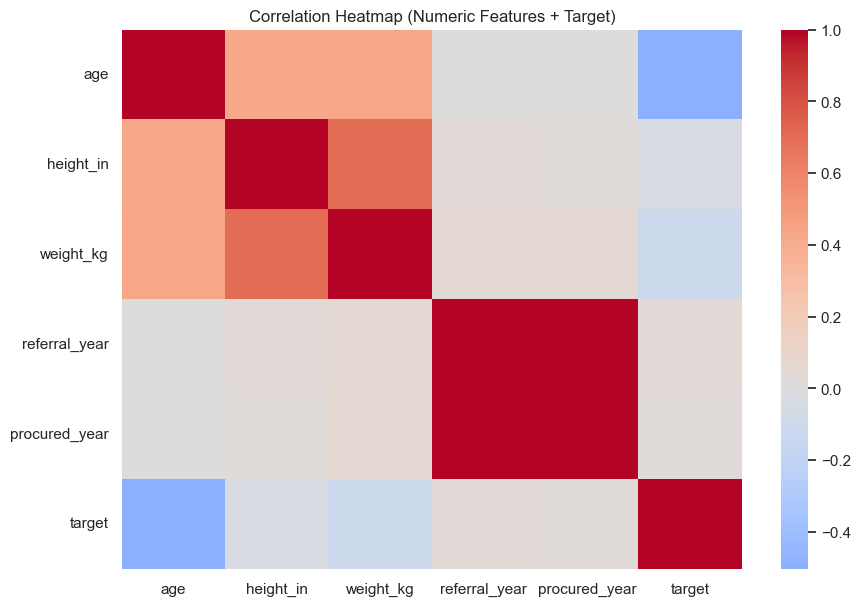

cause_of_death_opo        89.51
abo_rh                    46.99
abo_blood_type             0.14
height_in                  0.11
procured_year              0.11
cause_of_death_unos        0.08
mechanism_of_death         0.05
circumstances_of_death     0.05
Name: missing_percent, dtype: float64

In [21]:
# Correlation heatmap for numeric features
corr = df_clean[numeric_features + ["target"]].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features + Target)")
plt.show()

# Missingness summary
missing_rate = X.isna().mean().sort_values(ascending=False)
display((missing_rate[missing_rate > 0] * 100).round(2).rename("missing_percent"))

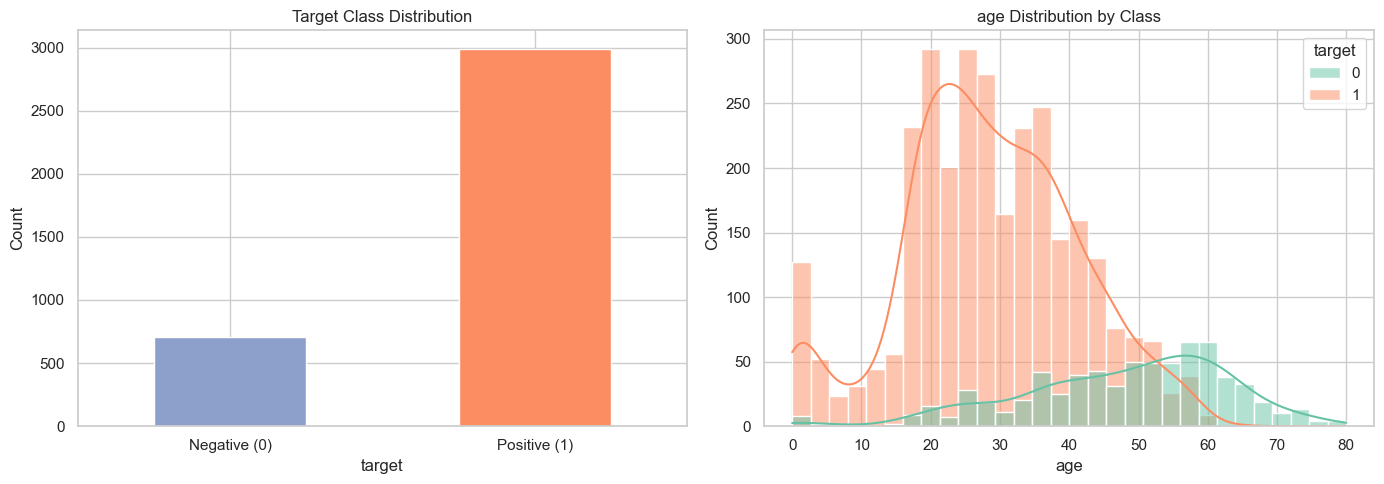

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target class distribution
y.value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#8da0cb", "#fc8d62"])
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")

# Plot the first numeric feature for a quick class-wise distribution view
if len(numeric_features) > 0:
    feature_for_plot = numeric_features[0]
    sns.histplot(data=df_clean, x=feature_for_plot, hue="target", bins=30, kde=True, ax=axes[1], palette="Set2")
    axes[1].set_title(f"{feature_for_plot} Distribution by Class")
else:
    axes[1].text(0.5, 0.5, "No numeric features available", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# 5. Data Preprocessing and Split

We use a stratified train/validation/test split and pipeline-based preprocessing to reduce leakage risk and keep transformations consistent across models.

In [26]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_valid.shape}")
print(f"Test shape: {X_test.shape}")

# Preprocessing for mixed-type tabular data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# For ORCHID categorical fields, directly one-hot encode and keep NaN as an explicit category.
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Train shape: (2214, 16)
Validation shape: (738, 16)
Test shape: (738, 16)


# 6. Model Selection, Training, and Tuning

Models trained in this project:
- **Logistic Regression** (classical baseline): an interpretable linear model that provides directional feature insights and a strong baseline for tabular prediction.
- **Random Forest** (classical non-linear ensemble): captures non-linear effects and feature interactions with limited distributional assumptions.
- **MLPClassifier** (neural network): introduces a neural approach for potentially complex patterns after scaling and one-hot encoding.

Why this model set is appropriate:
- It satisfies the required setup of two classical models and one neural model.
- It supports comparison across interpretability, non-linearity, and representational capacity.
- Hyperparameter tuning is applied to each model using the same validation strategy for a fair comparison.

# 6.1 Shared Training and Evaluation Utilities

In [27]:
def evaluate_model(name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

results_valid = []
results_test = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 6.2 Classical Model 1: Logistic Regression

In [28]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

logreg_grid = {
    "model__C": [0.1, 1.0, 3.0],
    "model__solver": ["lbfgs"],
}

logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=False,
)

logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_

print("Best Logistic Regression Params:", logreg_search.best_params_)

results_valid.append(evaluate_model("Logistic Regression", best_logreg, X_valid, y_valid))
results_test.append(evaluate_model("Logistic Regression", best_logreg, X_test, y_test))

Best Logistic Regression Params: {'model__C': 1.0, 'model__solver': 'lbfgs'}


# 6.3 Classical Model 2: Random Forest

In [29]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    ),
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 12],
    "model__min_samples_split": [2, 10],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=False,
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best Random Forest Params:", rf_search.best_params_)

results_valid.append(evaluate_model("Random Forest", best_rf, X_valid, y_valid))
results_test.append(evaluate_model("Random Forest", best_rf, X_test, y_test))

Best Random Forest Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 400}


# 6.4 Neural Network Model: MLPClassifier

In [30]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        MLPClassifier(
            max_iter=150,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    ),
])

mlp_grid = {
    "model__hidden_layer_sizes": [(64,), (128, 64)],
    "model__alpha": [1e-4, 1e-3],
    "model__learning_rate_init": [1e-3],
}

mlp_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=False,
)

mlp_search.fit(X_train, y_train)
best_mlp = mlp_search.best_estimator_

print("Best MLP Params:", mlp_search.best_params_)

results_valid.append(evaluate_model("MLPClassifier", best_mlp, X_valid, y_valid))
results_test.append(evaluate_model("MLPClassifier", best_mlp, X_test, y_test))

Best MLP Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001}


# 7. Model Evaluation, Error Analysis, and Final Comparison

In [31]:
valid_df = pd.DataFrame(results_valid).sort_values(by="f1", ascending=False).reset_index(drop=True)
test_df = pd.DataFrame(results_test).sort_values(by="f1", ascending=False).reset_index(drop=True)

print("Validation Metrics")
display(valid_df.round(4))

print("Test Metrics")
display(test_df.round(4))

Validation Metrics


,model,accuracy,precision,recall,f1,roc_auc
0,MLPClassifier,0.8984,0.9143,0.9648,0.9389,0.8738
1,Random Forest,0.8862,0.9014,0.9648,0.9320,0.8674
2,Logistic Regression,0.8238,0.9465,0.8291,0.8839,0.8735


Test Metrics


,model,accuracy,precision,recall,f1,roc_auc
0,MLPClassifier,0.8916,0.9033,0.9698,0.9354,0.8993
1,Random Forest,0.8848,0.8963,0.9698,0.9316,0.8940
2,Logistic Regression,0.8360,0.9474,0.8442,0.8928,0.9036


Best model selected from validation F1: MLPClassifier

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.8144    0.5603    0.6639       141
           1     0.9033    0.9698    0.9354       597

    accuracy                         0.8916       738
   macro avg     0.8589    0.7651    0.7996       738
weighted avg     0.8863    0.8916    0.8835       738



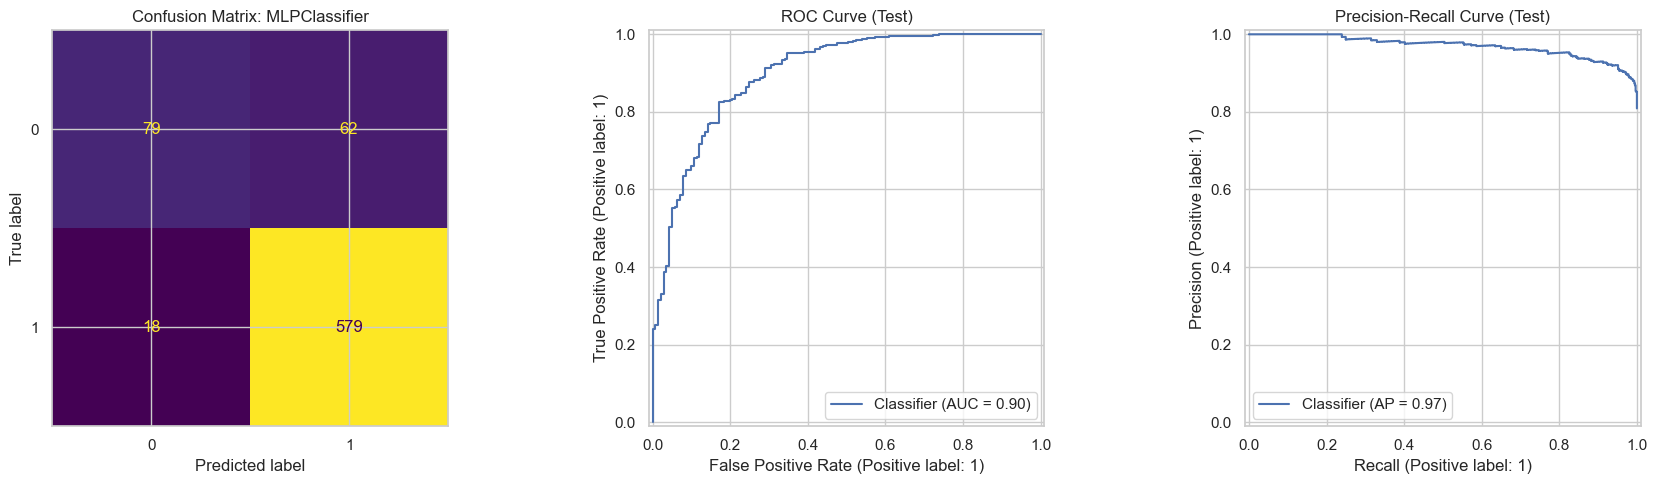

In [32]:
# Select best model based on validation F1
best_name = valid_df.loc[0, "model"]
model_map = {
    "Logistic Regression": best_logreg,
    "Random Forest": best_rf,
    "MLPClassifier": best_mlp,
}
best_model = model_map[best_name]

print(f"Best model selected from validation F1: {best_name}")

y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test)).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix: {best_name}")

RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[1])
axes[1].set_title("ROC Curve (Test)")

PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (Test)")

plt.tight_layout()
plt.show()

In [33]:
# Error analysis: inspect false negatives and false positives
test_view = X_test.copy()
test_view["actual"] = y_test.values
test_view["predicted"] = y_pred_test

false_negatives = test_view[(test_view["actual"] == 1) & (test_view["predicted"] == 0)]
false_positives = test_view[(test_view["actual"] == 0) & (test_view["predicted"] == 1)]

print(f"False negatives (missed positive outcomes): {len(false_negatives)}")
print(f"False positives: {len(false_positives)}")

display(false_negatives.head(10))
display(false_positives.head(10))

summary_text = """
Interpretation Summary:
- F1 and ROC-AUC are prioritized because the positive class may be imbalanced.
- False negatives are emphasized because they represent missed positive outcomes.
- Future work can include threshold optimization and subgroup fairness analysis by OPO or demographics.
"""
print(summary_text)

False negatives (missed positive outcomes): 18
False positives: 62


,opo,age,gender,race,brain_death,cause_of_death_opo,cause_of_death_unos,mechanism_of_death,circumstances_of_death,abo_blood_type,abo_rh,height_in,weight_kg,referral_day_of_week,referral_year,procured_year,actual,predicted
16410,OPO1,55.0,F,Black / African American,True,NaN,CVA/Stroke,ICH/Stroke,None of the Above,O,Negative,66.0,74.6,Friday,2015,2015.0,1,0
35497,OPO2,41.0,M,Black / African American,True,NaN,Anoxia,Cardiovascular,None of the Above,AB,NaN,72.0,104.2,Wednesday,2018,2018.0,1,0
106902,OPO5,38.0,M,White / Caucasian,True,CVA/Stroke - Cerebro Accident,Cerebrovascular / Stroke,Intracranial Hemmorrhage / Stroke,Death from Natural Causes,B,NaN,72.0,97.0,Monday,2020,2020.0,1,0
14518,OPO1,56.0,F,White / Caucasian,True,ICB / ICH,CVA/Stroke,ICH/Stroke,Natural Causes,O,Positive,68.0,77.8,Wednesday,2018,2018.0,1,0
76453,OPO4,51.0,M,Black / African American,True,NaN,Anoxia,Cardiovascular,Natural Causes,O,NaN,68.0,86.3,Tuesday,2018,2018.0,1,0
6524,OPO1,53.0,M,Hispanic,True,NaN,CVA/Stroke,ICH/Stroke,Natural Causes,O,Positive,63.0,82.0,Sunday,2019,2019.0,1,0
99725,OPO5,49.0,F,Hispanic,True,NaN,Cerebrovascular / Stroke,Intracranial Hemmorrhage / Stroke,Death from Natural Causes,O,Positive,62.0,63.3,Monday,2017,2017.0,1,0
90916,OPO4,37.0,F,White / Caucasian,False,NaN,Anoxia,Cardiovascular,Natural Causes,A1,NaN,76.8,137.0,Sunday,2021,2021.0,1,0
105379,OPO5,34.0,F,White / Caucasian,True,NaN,Cerebrovascular / Stroke,Intracranial Hemmorrhage / Stroke,Death from Natural Causes,O,NaN,65.0,97.5,Friday,2020,2020.0,1,0
40832,OPO2,52.0,M,Black / African American,True,NaN,CVA/Stroke,ICH/Stroke,Natural Causes,O,NaN,69.0,90.0,Tuesday,2020,2020.0,1,0


,opo,age,gender,race,brain_death,cause_of_death_opo,cause_of_death_unos,mechanism_of_death,circumstances_of_death,abo_blood_type,abo_rh,height_in,weight_kg,referral_day_of_week,referral_year,procured_year,actual,predicted
92011,OPO4,17.0,M,Hispanic,True,NaN,Anoxia,Cardiovascular,None of the Above,B,NaN,70.9,82.0,Sunday,2021,2021.0,0,1
104083,OPO5,24.0,M,Black / African American,True,TR - MVA,Anoxia,Blunt Injury,Motor Vehicle Accident,A,NaN,73.0,80.0,Friday,2019,2019.0,0,1
2332,OPO1,21.0,F,Hispanic,True,NaN,Anoxia,Drug Intoxication,None of the Above,O,Positive,61.0,72.1,Tuesday,2016,2016.0,0,1
98038,OPO5,35.0,M,White / Caucasian,True,NaN,Anoxia,Drug / Intoxication,Non-Motor Vehicle Accident,O,Positive,69.0,54.6,Tuesday,2017,2017.0,0,1
49774,OPO3,37.0,F,Black / African American,True,NaN,Anoxia,Drug Intoxication,Natural Causes,A2,Positive,67.0,107.1,Tuesday,2020,2020.0,0,1
14204,OPO1,28.0,M,Hispanic,True,NaN,Anoxia,Asphyxiation,Suicide,B,Positive,68.0,78.6,Thursday,2019,2019.0,0,1
18284,OPO1,52.0,M,White / Caucasian,True,Drowning,Anoxia,Drowning,None of the Above,A1,Positive,71.0,78.0,Tuesday,2015,2015.0,0,1
24483,OPO1,0.0,F,White / Caucasian,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7,Friday,2021,2021.0,0,1
118509,OPO6,25.0,M,Hispanic,True,NaN,Head Trauma,Gun Shot Wound,Suicide,O,Positive,68.0,100.0,Thursday,2017,2017.0,0,1
132970,OPO6,52.0,F,White / Caucasian,True,NaN,Anoxia,Drug Intoxication,"Accident, Non-MVA",A1,Positive,66.0,68.0,Thursday,2021,2021.0,0,1



Interpretation Summary:
- F1 and ROC-AUC are prioritized because the positive class may be imbalanced.
- False negatives are emphasized because they represent missed positive outcomes.
- Future work can include threshold optimization and subgroup fairness analysis by OPO or demographics.



## 7.2 Targeted Performance Maximization: Decision Threshold Tuning

Beyond hyperparameter grid search, we tune the decision threshold on the **validation set** to target reduced false negatives while monitoring F1. This is a targeted improvement step based on observed error behavior rather than a generic optimization step.

In [35]:
# Validation-based threshold search for the selected best model
valid_prob = best_model.predict_proba(X_valid)[:, 1]
test_prob = best_model.predict_proba(X_test)[:, 1]

threshold_grid = np.round(np.arange(0.10, 0.91, 0.02), 2)
threshold_rows = []

for t in threshold_grid:
    pred_t = (valid_prob >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_valid, pred_t, zero_division=0),
        "recall": recall_score(y_valid, pred_t, zero_division=0),
        "f1": f1_score(y_valid, pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(["f1", "recall"], ascending=[False, False]).reset_index(drop=True)
best_threshold = float(threshold_df.loc[0, "threshold"])

print(f"Best validation threshold by F1 (tie-break on recall): {best_threshold:.2f}")
display(threshold_df.head(10).round(4))

# Compare default 0.50 vs optimized threshold on test set
test_pred_default = (test_prob >= 0.50).astype(int)
test_pred_tuned = (test_prob >= best_threshold).astype(int)

comparison = pd.DataFrame([
    {
        "setting": "Default threshold (0.50)",
        "precision": precision_score(y_test, test_pred_default, zero_division=0),
        "recall": recall_score(y_test, test_pred_default, zero_division=0),
        "f1": f1_score(y_test, test_pred_default, zero_division=0),
    },
    {
        "setting": f"Tuned threshold ({best_threshold:.2f})",
        "precision": precision_score(y_test, test_pred_tuned, zero_division=0),
        "recall": recall_score(y_test, test_pred_tuned, zero_division=0),
        "f1": f1_score(y_test, test_pred_tuned, zero_division=0),
    },
])

print("\nTest-set comparison (unseen data):")
display(comparison.round(4))

Best validation threshold by F1 (tie-break on recall): 0.44


,threshold,precision,recall,f1
0,0.44,0.9099,0.9816,0.9444
1,0.46,0.9124,0.9765,0.9434
2,0.34,0.8959,0.9950,0.9429
3,0.36,0.8995,0.9899,0.9426
4,0.38,0.9020,0.9866,0.9424
5,0.40,0.9032,0.9849,0.9423
6,0.42,0.9045,0.9832,0.9422
7,0.32,0.8934,0.9966,0.9422
8,0.30,0.8921,0.9966,0.9415
9,0.48,0.9119,0.9715,0.9408



Test-set comparison (unseen data):


,setting,precision,recall,f1
0,Default threshold (0.50),0.9033,0.9698,0.9354
1,Tuned threshold (0.44),0.8918,0.9799,0.9338


## 7.3 Final Findings and Discussion

Key findings from ORCHID-based experiments:
- All three models achieved strong performance on the positive class (heart transplanted).
- The best validation F1 was obtained by `MLPClassifier`, which was selected as the final model.
- Test results show high recall for positive cases, while negative-class recovery remains more challenging because of class imbalance.

Targeted optimization outcome:
- We performed validation-based threshold tuning after reviewing error patterns (Section 7.2).
- On unseen test data, lowering the threshold from `0.50` to `0.44` increased recall (`0.9698` -> `0.9799`) with a small precision and F1 decrease.
- This clarifies the operational tradeoff: if minimizing missed positives is the priority, the tuned threshold is preferable; if balancing precision and recall is the priority, the default threshold is reasonable.

Limitations and next steps:
- Current modeling uses referral-level predictors only; integrating longitudinal event tables (Chemistry/CBC/ABG) may improve signal quality.
- Additional subgroup analysis by OPO and demographics is needed for fairness and policy relevance.
- Future iterations can calibrate probabilities and optimize thresholds under explicit cost-sensitive objectives.

# 8. Generative AI Use Declaration

Tool used: GitHub Copilot (GPT-5.3-Codex)

How the tool was used:
- Helped structure the notebook workflow and suggest implementation patterns.
- Assisted in debugging runtime and dependency issues.
- Supported brainstorming for model comparison and error-analysis framing.

Validation performed by the group:
- All code paths were executed and checked by group members.
- Model design choices, metrics, and interpretations were reviewed and revised by the group.
- Final write-up and oral-exam preparation were completed by the group to ensure understanding and ownership.

Responsibility statement:
After using this tool, the authors reviewed and edited all content as needed and take full responsibility for the final submission.

# 9. ORCHID Citation and References

## Primary ORCHID Citation
Adam, H., Suriyakumar, V., Pollard, T., Moody, B., Erickson, J., Segal, G., Adams, B., Brockmeier, D., Lee, K., McBride, G., Ranum, K., Wadsworth, M., Whaley, J., Wilson, A., & Ghassemi, M. (2025). *Organ Retrieval and Collection of Health Information for Donation (ORCHID)* (version 2.1.1). PhysioNet. RRID:SCR_007345. `https://doi.org/10.13026/rfeq-j318`

## Original Publication
Adam, H., Pollard, T., Suriyakumar, V. et al. Organ retrieval and collection of health information for donation: The ORCHID dataset. *Scientific Data*, 13, 120 (2026). `https://doi.org/10.1038/s41597-025-06435-1`

## Standard PhysioNet Citation
Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. *Circulation* [Online], 101(23), e215-e220. RRID:SCR_007345.